# Drishti — Indian Currency Classifier

Trains the specialist model behind **Money mode**. A note is a closed-set classification
problem with six classes, so it does not need the VLM — a MobileNet is smaller, faster and
more accurate here, which is the routing principle the whole project rests on (`DEC-012`).

**Backbone: MobileNetV3-Small.** ~2.5M parameters, designed for phones, and the Phase-5
Android port is the reason to pick it now rather than a ResNet that would have to be
replaced later.

## The metric that matters is not accuracy

Misclassification cost here is **asymmetric in rupees**. Calling a ₹500 note a ₹100 costs
the user ₹400; calling a ₹10 a ₹20 costs ₹10. Plain accuracy treats those identically, so
this notebook also reports **expected rupee error per identification** and a confusion
matrix weighted by value.

## Abstention, again

Same principle as the VLM (`DEC-016`) and medicine mode (`DEC-007`): for a blind user a
confident wrong answer is worse than "I can't tell". The model must decline below a
confidence threshold, and §6 sweeps that threshold rather than assuming one.

---

### Before running

Dataset: **`vishalmane109/indian-currency-note-images-dataset-2020`** — 4,002 images,
2.5 GB, licensed **CC0-1.0** (public domain, so images may be reproduced in the report).
Covers 10, 20, 50, 100, 200, 500 and 2000. Verified 2026-08-10; `DEC-022` requires the
licence check, so re-verify if you switch datasets.

```powershell
kaggle auth login                                    # OAuth, no token to store
python data/scripts/download_currency.py --dataset vishalmane109/indian-currency-note-images-dataset-2020
python data/scripts/organize_currency.py --src data/currency --dry-run
python data/scripts/organize_currency.py --src data/currency
```

The organize step is **not optional**. This dump stores every image flat inside
`training/`, `test/` and `validation/`, with the denomination in the *filename*
(`100_15.jpg`, `200.__1.jpg`, `2000__114.jpg`), while `ImageFolder` below takes class names
from *directories*. The script also refuses to guess: the denominations nest as strings —
`20` inside `200` inside `2000` — so a lenient parser could mislabel a whole class, and a
wrong label here becomes a wrong denomination spoken to someone who cannot check it
(`DEC-023`).

Expected layout once it has run — **eight** classes, 4002 images, near-balanced:

```
data/currency/
  10/  20/  50/  100/  200/  500/  2000/  background/
```

`background/` is 431 photos with **no note in frame**. It is a real class, not junk. Without
it the model's only options are seven denominations, so a photo of a table, a hand or a
blurred miss must come back as *some* amount — and currency mode would speak it. With it,
"there is no note here" is an answer the model can give. `app/modes/currency.py` maps that
class to reframing guidance rather than a denomination (`DEC-039`).

This also means **accuracy alone is doubly misleading here**: `background` is ~11% of the
data, so a model that learned nothing else could score 11% and a model that never predicts
it still looks fine. Read §4's rupee-weighted error and §5's per-class behaviour instead.

One caveat on §4's rupee metric: `class_value('background')` is ₹0, so calling a real ₹500
note `background` is scored as a ₹500 error. In reality that is a *cheap* failure — the user
retakes the photo — while the reverse, calling an empty table ₹500, is the expensive one.
The metric treats them alike; say so in the report rather than quietly averaging them.

**Two caveats to carry into the write-up:**

- The dataset's own splits are merged and re-split 70/15/15 below. Its images come from
  Google Images plus one phone camera, so near-duplicates across splits are likely and
  test accuracy will read high. §5's threshold sweep and §4's rupee-weighted error matter
  more than the headline number.
- Studio and web images are not what a blind user photographs. The augmentation in §1
  simulates tilt, glare, folds and a thumb over the note, but it cannot invent real wear.
  Budget some Phase-2 photos for ₹ notes and test on those before trusting ≥99%.

Colab: `Runtime → T4 GPU`. Training is short — a few minutes for a 6-class transfer-learn.

## 0. Setup — repo, dataset, paths

Run this first, on Colab or locally. It clones the repo when needed, fetches the dataset
from Kaggle and reshapes it into the folder-per-class layout `ImageFolder` requires.

**The 2.4 GB dataset is gitignored and is not in the repo.** Cloning gives you the code and
nothing to train on, which is why this cell downloads rather than assuming. It is also why
`git add .` should never be pointed at `data/currency`.

**On Colab, add your Kaggle token as a secret, not as a cell.** Key icon in the left
sidebar → new secret named `KAGGLE_API_TOKEN` → paste the token from kaggle.com → Settings
→ API → *Generate New Token* → switch on *Notebook access*. A token pasted into a cell gets
committed the moment you save the notebook.

Re-running is cheap: if `data/currency/` already has class folders, both steps are skipped.


In [1]:
# Environment setup. Runs the same on Colab and on a laptop; only the paths differ.
#
# The dataset is 2.4 GB and gitignored, so it does NOT arrive with the repo -- cloning on
# Colab gives you the code and nothing to train on. It is fetched from Kaggle here instead,
# which is also why it never needs to be pushed anywhere.
import os
import subprocess
import sys
from pathlib import Path

DATASET = 'vishalmane109/indian-currency-note-images-dataset-2020'   # CC0-1.0, DEC-022
REPO_URL = 'https://github.com/DevGurav/Drishti.git'

ON_COLAB = 'google.colab' in sys.modules or Path('/content').is_dir()

if ON_COLAB:
    PROJECT = Path('/content/drishti')
    if not PROJECT.exists():
        subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(PROJECT)], check=True)
    else:
        subprocess.run(['git', '-C', str(PROJECT), 'pull', '--ff-only'], check=False)

    # Kaggle credentials come from Colab Secrets, never from a cell. Add a secret named
    # KAGGLE_API_TOKEN (kaggle.com -> Settings -> API -> Generate New Token) and enable it
    # for this notebook via the key icon in the left sidebar.
    if not os.environ.get('KAGGLE_API_TOKEN'):
        try:
            from google.colab import userdata
            os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
        except Exception as e:
            raise SystemExit(
                'No Kaggle credentials. Add a Colab secret named KAGGLE_API_TOKEN\n'
                '(key icon in the left sidebar, "Notebook access" on), then re-run.\n'
                f'Underlying error: {type(e).__name__}: {e}'
            )
else:
    PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

RAW_DIR = PROJECT / 'data' / 'currency_raw'
DATA_DIR = PROJECT / 'data' / 'currency'
OUT_PATH = PROJECT / 'models' / 'currency_mobilenetv3.pt'

# ImageFolder needs one directory per class. Skip both steps if that already exists, so
# re-running the notebook does not re-download 2.4 GB.
# The class folders must be *denominations*. Checking merely for "some subdirectory"
# would accept the raw dump, whose single 'Indian currency dataset v1/' folder would
# become one class -- and a one-class model answers the same denomination every time.
organized = sorted(p.name for p in DATA_DIR.iterdir()
                   if p.is_dir() and p.name.isdigit()) if DATA_DIR.is_dir() else []
if organized:
    print(f'dataset already organized: {DATA_DIR}\nclasses: {organized}')
else:
    if ON_COLAB:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)
    subprocess.run(
        [sys.executable, str(PROJECT / 'data' / 'scripts' / 'download_currency.py'),
         '--dataset', DATASET, '--out', str(RAW_DIR)], check=True)
    # Flat filenames -> folder-per-class. Refuses to guess on anything it cannot parse,
    # because a wrong label here becomes a wrong denomination spoken aloud (DEC-023).
    subprocess.run(
        [sys.executable, str(PROJECT / 'data' / 'scripts' / 'organize_currency.py'),
         '--src', str(RAW_DIR), '--out', str(DATA_DIR)], check=True)

print(f'\nproject : {PROJECT}')
print(f'data    : {DATA_DIR}')
print(f'model   : {OUT_PATH}')



project : /content/drishti
data    : /content/drishti/data/currency
model   : /content/drishti/models/currency_mobilenetv3.pt


In [2]:
%pip install -q torch torchvision scikit-learn matplotlib

import json, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms

# DATA_DIR and OUT_PATH come from the setup cell above -- they differ between Colab
# (/content/drishti) and a laptop, and hardcoding '../' broke every Colab run.
assert 'DATA_DIR' in dir(), 'run the setup cell above first'

IMG_SIZE = 224
BATCH = 32
EPOCHS = 12
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

if not DATA_DIR.exists():
    raise SystemExit(
        f'{DATA_DIR} not found.\n'
        'Download a licensed Indian-currency dataset first:\n'
        '  python data/scripts/download_currency.py --dataset <owner>/<slug>\n'
        'then set DATA_DIR to the extracted folder.'
    )

device: cuda


## 1. Data and augmentation

Augmentation is chosen to match how a blind user actually photographs a note, not to pad
the dataset generically: notes arrive **folded, worn, partially in frame, at any rotation,
and under bad indoor light**. A model trained only on flat well-lit scans will score well
here and fail in the hand.

Horizontal flip is included (a note handed over upside-down is the same note); vertical
flip is too, for the same reason.

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.55, 1.0)),   # partially framed notes
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),                               # handheld tilt
    transforms.ColorJitter(brightness=0.45, contrast=0.35,
                           saturation=0.25, hue=0.03),           # indoor light, yellow bulbs
    transforms.RandomPerspective(distortion_scale=0.35, p=0.5),  # curved/folded notes
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.35, scale=(0.02, 0.18)),        # thumb over the note
])

eval_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full = datasets.ImageFolder(DATA_DIR)
CLASSES = full.classes
print(f'{len(full)} images across {len(CLASSES)} classes: {CLASSES}')

n_val = int(0.15 * len(full))
n_test = int(0.15 * len(full))
n_train = len(full) - n_val - n_test
gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(full, [n_train, n_val, n_test], generator=gen)

# Subset shares the parent dataset, so transforms are attached per split via a wrapper.
class WithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, tf):
        self.subset, self.tf = subset, tf
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        return self.tf(img), label

train_dl = DataLoader(WithTransform(train_ds, train_tf), batch_size=BATCH, shuffle=True, num_workers=2)
val_dl = DataLoader(WithTransform(val_ds, eval_tf), batch_size=BATCH, num_workers=2)
test_dl = DataLoader(WithTransform(test_ds, eval_tf), batch_size=BATCH, num_workers=2)
print(f'train {n_train} · val {n_val} · test {n_test}')

4002 images across 8 classes: ['10', '100', '20', '200', '2000', '50', '500', 'background']
train 2802 · val 600 · test 600


## 2. Model — MobileNetV3-Small, transfer learned

In [4]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, len(CLASSES))
model = model.to(DEVICE)

params = sum(p.numel() for p in model.parameters())
print(f'MobileNetV3-Small · {params/1e6:.2f}M parameters · {len(CLASSES)} classes')

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 103MB/s]


MobileNetV3-Small · 1.53M parameters · 8 classes


In [5]:
def run_epoch(loader, train: bool):
    model.train(train)
    total_loss = correct = seen = 0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            seen += y.size(0)
    return total_loss / seen, correct / seen


best_val, best_state = 0.0, None
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_dl, True)
    va_loss, va_acc = run_epoch(val_dl, False)
    scheduler.step()
    flag = ''
    if va_acc > best_val:
        best_val = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        flag = '  <- best'
    print(f'epoch {epoch:2d}  train {tr_acc:.3f}  val {va_acc:.3f}  '
          f'({time.time()-t0:.0f}s){flag}')

model.load_state_dict(best_state)
print(f'\nbest validation accuracy: {best_val:.4f}')

epoch  1  train 0.723  val 0.823  (202s)  <- best
epoch  2  train 0.886  val 0.928  (189s)  <- best
epoch  3  train 0.924  val 0.950  (182s)  <- best
epoch  4  train 0.930  val 0.905  (185s)
epoch  5  train 0.950  val 0.973  (183s)  <- best
epoch  6  train 0.960  val 0.975  (188s)  <- best
epoch  7  train 0.966  val 0.980  (187s)  <- best
epoch  8  train 0.969  val 0.980  (188s)
epoch  9  train 0.975  val 0.985  (186s)  <- best
epoch 10  train 0.978  val 0.983  (187s)
epoch 11  train 0.978  val 0.983  (185s)
epoch 12  train 0.980  val 0.983  (186s)

best validation accuracy: 0.9850


## 3. Test-set predictions

In [6]:
model.eval()
probs_all, y_all = [], []
with torch.no_grad():
    for x, y in test_dl:
        probs_all.append(torch.softmax(model(x.to(DEVICE)), dim=1).cpu())
        y_all.append(y)

probs = torch.cat(probs_all).numpy()
y_true = torch.cat(y_all).numpy()
y_pred = probs.argmax(1)
conf = probs.max(1)

acc = (y_pred == y_true).mean()
print(f'test accuracy: {acc:.4f}  (target >= 0.99)   n={len(y_true)}')

test accuracy: 0.9883  (target >= 0.99)   n=600


## 4. Rupee-weighted error

The project-specific metric. Two models with identical accuracy are not equally good if one
confuses ₹10 with ₹20 and the other confuses ₹100 with ₹500.

In [7]:
def class_value(name: str) -> float:
    """Rupee value from the folder name, tolerating '500', 'Rs500', '500_note'."""
    digits = ''.join(ch for ch in str(name) if ch.isdigit())
    return float(digits) if digits else 0.0

VALUES = np.array([class_value(c) for c in CLASSES])
print('class values:', dict(zip(CLASSES, VALUES)))

rupee_err = np.abs(VALUES[y_pred] - VALUES[y_true])
print(f'\nexpected rupee error per identification : Rs {rupee_err.mean():.2f}')
print(f'worst single error                      : Rs {rupee_err.max():.0f}')
print(f'errors costing more than Rs 100         : {(rupee_err > 100).sum()} of {len(y_true)}')

class values: {'10': np.float64(10.0), '100': np.float64(100.0), '20': np.float64(20.0), '200': np.float64(200.0), '2000': np.float64(2000.0), '50': np.float64(50.0), '500': np.float64(500.0), 'background': np.float64(0.0)}

expected rupee error per identification : Rs 5.37
worst single error                      : Rs 1990
errors costing more than Rs 100         : 6 of 600


              precision    recall  f1-score   support

          10      0.986     0.986     0.986        72
         100      1.000     1.000     1.000        76
          20      1.000     0.959     0.979        74
         200      0.959     1.000     0.979        93
        2000      1.000     0.988     0.994        86
          50      0.988     0.988     0.988        80
         500      0.983     1.000     0.991        57
  background      1.000     0.984     0.992        62

    accuracy                          0.988       600
   macro avg      0.989     0.988     0.989       600
weighted avg      0.989     0.988     0.988       600



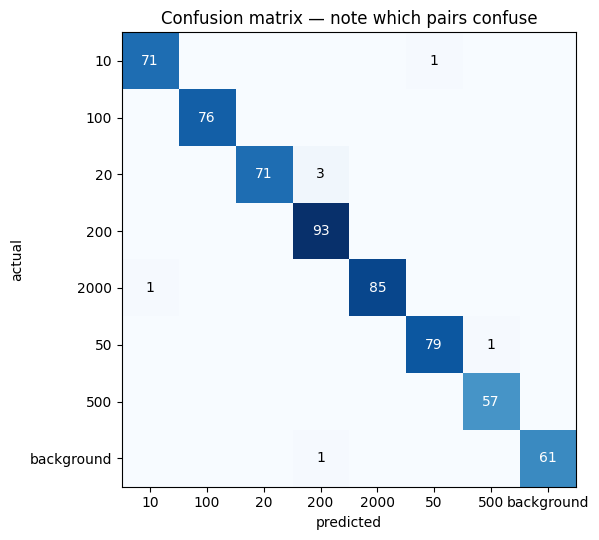


costliest confusions (by rupee impact):
  Rs   1990 total  ·  1 x  actual 2000 -> predicted 10
  Rs    540 total  ·  3 x  actual 20 -> predicted 200
  Rs    450 total  ·  1 x  actual 50 -> predicted 500
  Rs    200 total  ·  1 x  actual background -> predicted 200
  Rs     40 total  ·  1 x  actual 10 -> predicted 50


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES)), CLASSES)
ax.set_yticks(range(len(CLASSES)), CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Confusion matrix — note which pairs confuse')
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout(); plt.show()

# The expensive confusions are the ones worth reporting, not the frequent ones.
print('\ncostliest confusions (by rupee impact):')
pairs = [(cm[i, j] * abs(VALUES[i] - VALUES[j]), CLASSES[i], CLASSES[j], cm[i, j])
         for i in range(len(CLASSES)) for j in range(len(CLASSES))
         if i != j and cm[i, j] > 0]
for cost, actual, pred, n in sorted(pairs, reverse=True)[:6]:
    print(f'  Rs {cost:6.0f} total  ·  {n} x  actual {actual} -> predicted {pred}')

## 5. Confidence threshold

`app/modes/currency.py` declines below a threshold rather than guessing. That constant was
set to 0.85 by assumption when the mode was scaffolded — this sweep replaces the assumption
with a measurement.

Read it the same way as the VLM abstention trade-off: a **refusal costs a retaken photo, a
wrong answer costs money.**

In [9]:
print(f"{'thresh':>7} {'answered':>9} {'acc|answered':>13} {'refused':>8} {'Rs err':>8}")
rows = []
for t in [0.0, 0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99]:
    keep = conf >= t
    if keep.sum() == 0:
        continue
    acc_k = (y_pred[keep] == y_true[keep]).mean()
    err_k = np.abs(VALUES[y_pred[keep]] - VALUES[y_true[keep]]).mean()
    rows.append((t, keep.mean(), acc_k, 1 - keep.mean(), err_k))
    print(f'{t:7.2f} {keep.mean():9.1%} {acc_k:13.4f} {1-keep.mean():8.1%} {err_k:8.2f}')

# Cheapest threshold that clears the >=99% bar while still answering most of the time.
viable = [r for r in rows if r[2] >= 0.99 and r[1] >= 0.80]
if viable:
    best = min(viable, key=lambda r: r[0])
    print(f'\nrecommended CONFIDENCE_THRESHOLD = {best[0]:.2f} '
          f'(answers {best[1]:.0%} of the time at {best[2]:.3f} accuracy)')
else:
    print('\nNo threshold reaches 99% while answering >=80% of the time.')
    print('Collect more data before shipping Money mode -- do not lower the bar.')

 thresh  answered  acc|answered  refused   Rs err
   0.00    100.0%        0.9883     0.0%     5.37
   0.50     98.7%        0.9916     1.3%     1.32
   0.70     96.7%        0.9931     3.3%     1.00
   0.80     93.8%        0.9947     6.2%     0.96
   0.85     90.3%        0.9945     9.7%     1.00
   0.90     85.0%        0.9961    15.0%     0.71
   0.95     61.5%        0.9973    38.5%     0.49
   0.99      5.0%        0.9667    95.0%     6.00

recommended CONFIDENCE_THRESHOLD = 0.50 (answers 99% of the time at 0.992 accuracy)


## 6. Export

Class names and preprocessing travel **inside** the checkpoint. The app must never rely on
a hardcoded class order — a dataset with different folders would silently relabel every
prediction, and calling a ₹500 note ₹10 is exactly the failure this project cannot have.

In [10]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    'state_dict': model.state_dict(),
    'arch': 'mobilenet_v3_small',
    'classes': CLASSES,
    'img_size': IMG_SIZE,
    'mean': IMAGENET_MEAN,
    'std': IMAGENET_STD,
    'test_accuracy': float(acc),
    'rupee_error': float(rupee_err.mean()),
    'trained': time.strftime('%Y-%m-%d'),
}, OUT_PATH)

print(f'saved {OUT_PATH}  ({OUT_PATH.stat().st_size/1e6:.1f} MB)')
print(f'test accuracy {acc:.4f} · rupee error Rs {rupee_err.mean():.2f}')
print('\nLoad it in the app with app/engines/currency_cnn.py::CurrencyClassifier')

saved /content/drishti/models/currency_mobilenetv3.pt  (6.2 MB)
test accuracy 0.9883 · rupee error Rs 5.37

Load it in the app with app/engines/currency_cnn.py::CurrencyClassifier


## Record for the report

1. Test accuracy against the ≥99% bar, **and** expected rupee error — the second is the
   metric that reflects what a wrong answer actually costs a user.
2. The costliest confusion pairs. If ₹100↔₹500 appears, say so and explain the mitigation
   (threshold, more data for that pair) rather than reporting only the headline accuracy.
3. The chosen `CONFIDENCE_THRESHOLD` and the refusal rate it implies. Update
   `app/modes/currency.py` and add a decision entry to `docs/BUILD_PLAN.md`.
4. Copy the checkpoint into `models/` (gitignored — record the numbers, not the weights).

**If accuracy is well below 99%,** the usual cause is a dataset of clean scans that does not
match handheld photos. Fix it with data, not by weakening the augmentation: shoot your own
notes under the conditions in `docs/data_collection_guide.md` and fine-tune on those.